# Preliminary

For grading purposes, please answer the following:
1. Are you a post-quals Math PhD student?
2. Are you intending to be graded according to the "heavy load" or "light load" grading scheme, as described in the syllabus?

As a reminder, the default is for post-quals Math students to be graded according to the light load and all others to be graded according to the heavy load. Please describe here or discuss with the instructor if you feel that an exception should be made in your case. 

1. No
2. Heavy load

# Summary of Key Concepts

## Main Ideas

### 1. Overfitting
**Problem**: Models with too many parameters fit the training data perfectly but fail to generalize to new data.

**Solution**: Use cross-validation to select model complexity based on performance on unseen data.

### 2. Bias-Variance Tradeoff
- **Low polynomial degree (p)**: Underfitting (high bias, low variance)
- **Optimal p**: Good balance
- **High p**: Overfitting (low bias, high variance)

---

## Key Equations

### Polynomial Model
$$
\hat{y}(x) = \beta_0 + \beta_1 x + \beta_2 x^2 + \ldots + \beta_p x^p = \sum_{j=0}^{p} \beta_j x^j
$$

### Mean Squared Error (MSE)
$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}(x_i))^2
$$
- Measures average squared difference between predictions and true values
- Lower MSE = better fit
- **Training MSE**: Computed on data used to fit the model
- **Testing MSE**: Computed on held-out data (the real measure of performance!)

### Cross-Validation Split
For simple train-test split:
- **Training set**: First $n/2$ data points → fit model
- **Testing set**: Remaining $n/2$ points → evaluate model

---

## Important Functions

### 1. `mse(x, y, p)`
**Purpose**: Fit polynomial of degree p and compute MSE on the same data.

**Key steps**:
```python
def mse(x, y, p):
    # 1. Fit polynomial to data
    fit = np.polyfit(x, y, p)
    
    # 2. Get predictions
    y_pred = np.polyval(fit, x)
    
    # 3. Compute MSE
    return np.mean((y - y_pred)**2)
```

**Important**: This computes training MSE (fitting and evaluating on same data).

---

### 2. `mse_cv(x, y, p)`
**Purpose**: Implement cross-validation by splitting data into train and test sets.

**Key steps**:
```python
def mse_cv(x, y, p):
    # 1. Split data in half
    mid = len(x) // 2
    x_train, x_test = x[:mid], x[mid:]
    y_train, y_test = y[:mid], y[mid:]
    
    # 2. Fit ONLY on training data
    fit = np.polyfit(x_train, y_train, p)
    
    # 3. Evaluate on BOTH sets
    y_train_pred = np.polyval(fit, x_train)
    y_test_pred = np.polyval(fit, x_test)
    
    train_mse = np.mean((y_train - y_train_pred)**2)
    test_mse = np.mean((y_test - y_test_pred)**2)
    
    return train_mse, test_mse
```

**Critical rule**: Fit on training data ONLY, but evaluate on both.

---

### 3. `mse_kfold(x, y, p, k=5)`
**Purpose**: More robust cross-validation using k folds.

**Key steps**:
```python
def mse_kfold(x, y, p, k=5):
    # 1. Shuffle and split data into k folds
    indices = np.random.permutation(len(x))
    folds = np.array_split(indices, k)
    
    train_mses = []
    val_mses = []
    
    # 2. For each fold
    for fold_idx in range(k):
        # Use one fold for validation
        val_indices = folds[fold_idx]
        # Use remaining k-1 folds for training
        train_indices = np.concatenate([folds[j] for j in range(k) if j != fold_idx])
        
        # 3. Extract data (KEEP x AND y PAIRED!)
        x_train, y_train = x[train_indices], y[train_indices]
        x_val, y_val = x[val_indices], y[val_indices]
        
        # 4. Fit on training, evaluate on both
        fit = np.polyfit(x_train, y_train, p)
        y_train_pred = np.polyval(fit, x_train)
        y_val_pred = np.polyval(fit, x_val)
        
        train_mses.append(np.mean((y_train - y_train_pred)**2))
        val_mses.append(np.mean((y_val - y_val_pred)**2))
    
    # 5. Return averages across all k folds
    return np.mean(train_mses), np.mean(val_mses)
```

**Why k-fold is better**: Uses all data for both training and validation, averaged over k trials.

---

## Expected Behavior

### Training vs Testing MSE Curves

When plotting MSE vs polynomial degree p:

**Training MSE**: 
$$\text{MSE}_{\text{train}}(p) \searrow \text{ (monotonically decreasing)}$$
- Always decreases (or stays flat) as p increases
- More parameters = better fit to training data
- **If it increases, you have a bug!**

**Testing MSE**:
$$\text{MSE}_{\text{test}}(p) \text{ is U-shaped: } \searrow \text{ then } \nearrow$$
- Decreases initially (model learning true pattern)
- Reaches minimum at optimal p
- Increases for high p (overfitting to noise)

**Optimal Model**: 
$$p^* = \arg\min_p \text{MSE}_{\text{test}}(p)$$

---

## Critical Rules

### ✅ DO:
1. **Fit on training data only**: `np.polyfit(x_train, y_train, p)`
2. **Keep x and y paired**: When sorting/shuffling, apply same operation to both
3. **Use unique variable names**: `x_data` (synthetic), `x_housing` (real data)
4. **Evaluate on test set**: This determines model quality

### ❌ DON'T:
1. **Sort one without the other**: `x = np.sort(x)` but `y` unchanged → BREAKS PAIRING!
2. **Fit on test data**: Defeats the purpose of cross-validation
3. **Overwrite variables**: Reusing `x_data` for different datasets
4. **Trust training MSE alone**: It always looks good, even when overfitting!

---

## Typical Workflow

```python
# 1. Try different polynomial degrees
degrees = range(1, 16)
train_mses, test_mses = [], []

for p in degrees:
    train_mse, test_mse = mse_cv(x_data, y_data, p)
    train_mses.append(train_mse)
    test_mses.append(test_mse)

# 2. Plot both curves
plt.plot(degrees, train_mses, 'o-', label='Training MSE')
plt.plot(degrees, test_mses, 's-', label='Testing MSE')
plt.xlabel('Polynomial Degree p')
plt.ylabel('MSE')
plt.legend()
plt.show()

# 3. Find optimal polynomial degree
optimal_p = degrees[np.argmin(test_mses)]
print(f"Optimal polynomial degree: {optimal_p}")
```

---

## Debugging Checklist

If results look wrong:
- [ ] Does training MSE decrease with p?
- [ ] Are x and y still paired after any sorting/shuffling?
- [ ] Did I use different variable names for different datasets?
- [ ] Am I fitting on training data only?
- [ ] Is test MSE ≥ train MSE (usually true)?

# Coding exercises

In class, we generated some fake data and fit polynomials to the data. We noticed that higher-order polynomials did a good job of fitting the data, but a poor job of fitting new data that was generated in the same way. This is an example of **overfitting**.

In this assignment, we will use **cross validation** to combat overfitting by selecting a model that optimally describes data that was *not* used to fit the model.

Reminder: Once your notebook is complete, you should restart the kernel, run all of the cells in order, and make sure that no errors occur. Notebooks that run successfully without errors will be awarded one extra credit point.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Text(0, 0.5, 'y')

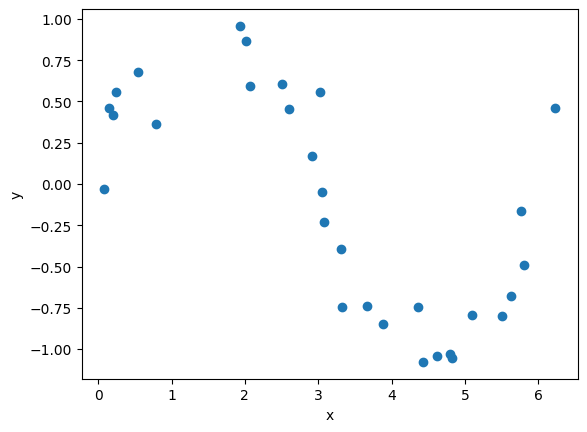

In [2]:
n = 30  # number of data points

# Simulated data:
x_data = 2*np.pi*np.random.rand(n)
noise_amp = 0.3
noise = noise_amp*np.random.randn(n)
y_data = np.sin(x_data) + noise

plt.plot(x_data, y_data, 'o')
plt.xlabel('x')
plt.ylabel('y')

In [3]:
# A polynomial fit:
p = 12
fit = np.polyfit(x_data, y_data, p)
beta_list = fit[::-1]  # flip the list so that it starts with beta0
print('Polynomial coefficients: \n', beta_list)


# The following function gives us the y value of our fitting curve given the x value:
def yhat(x, beta_list):
    '''
    Given the x value and the list of polynomial coefficients, return the y value.
    '''
    y = 0
    for p in range(len(beta_list)):
        y = y + beta_list[p]*x**p
        
    return y

Polynomial coefficients: 
 [-6.50004763e-01  9.93148636e+00 -2.59521101e+01  2.93465339e+01
 -1.44202446e+01 -4.74684087e-01  4.73888107e+00 -2.94488869e+00
  9.71463867e-01 -1.94579284e-01  2.36713510e-02 -1.61066065e-03
  4.70652419e-05]


In class, we used the function `np.polyfit()` to fit the data with a polynomial:
$$
\hat{y} = \beta_0 + \beta_1 x + \ldots + \beta_{p-1} x^{p-1}
$$

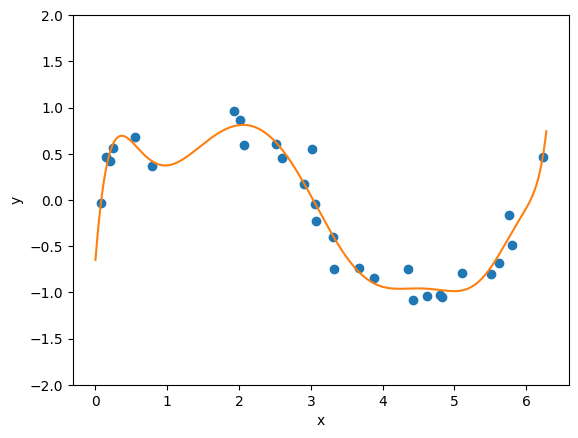

In [4]:
# Plot the data together with the fit.

x_pts = np.arange(0,2*np.pi,0.01)
y_fit = yhat(x_pts, beta_list)

plt.plot(x_data, y_data, 'o')
plt.xlabel('x')
plt.ylabel('y')
plt.plot(x_pts, y_fit)
plt.ylim(-2,2);

**Exercise 1** (3 points): Create a function `mse(x, y, p)` that fits a polynomial of order `p` to data `x` and `y` and returns the mean squared error from the fit.

How do we decide how good a fit like this is? To do this, we can use the mean squared error, which is the average squared distance between the data points and the curve at each x value in the dataset:
$$
\mathrm{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}(x_i))^2,
$$
where $(x_i, y_i)$ denotes one of the data points, and $\hat{y}(x)$ is the curve that fits the data. If the MSE is close to zero, then the curve is doing a good job of fitting the data.

In [5]:
## Solution ##
def mse(x,y,p):
    if len(x) != len(y):
        raise ValueError("Input arrays must have the same length")
    n = len(x)
    fit = np.polyfit(x, y, p)
    beta_list = fit[::-1]  # flip the list so that it starts with beta0
    yhats = yhat(x, beta_list)
    return sum((y[i] - yhats[i])**2 for i in range(n)) / n


**Exercise 2** (3 points): For the data that we generated above, make a plot of the MSE for different values of $p$. Make sure to label the axes appropriately. You should find that the MSE decreases as $p$ increases.

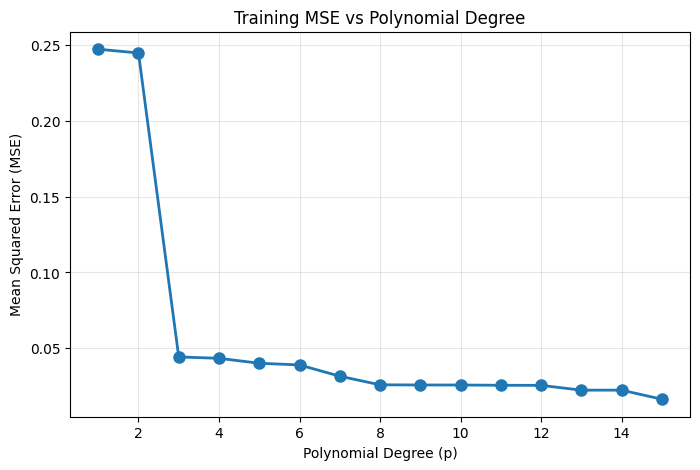

MSE for p=1: 0.2474
MSE for p=15: 0.0163
MSE decreases as p increases: True


In [11]:
## Solution ##

# Test polynomial degrees from 1 to 15
p_values = range(1, 16)
mse_values = []

for p in p_values:
    mse_val = mse(x_data, y_data, p)
    mse_values.append(mse_val)

# Plot MSE vs polynomial degree
plt.figure(figsize=(8, 5))
plt.plot(p_values, mse_values, 'o-', linewidth=2, markersize=8)
plt.xlabel('Polynomial Degree (p)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training MSE vs Polynomial Degree')
plt.grid(True, alpha=0.3)
plt.show()

print(f"MSE for p=1: {mse_values[0]:.4f}")
print(f"MSE for p=15: {mse_values[-1]:.4f}")
print(f"MSE decreases as p increases: {all(mse_values[i] >= mse_values[i+1] for i in range(len(mse_values)-1))}")


In class, we found that, although higher-order polynomials may fit the data very well, they typically won't do a great job at describing new data that was not used for the fit. The idea of **cross validation** is to split the data into a **training set** and a **testing set**. The training set is used for fitting, and the testing set is used to quantify the goodness of the fit.

**Exercise 3** (5 pts): Create a new version of the function from the previous exercise. Call this function `mse_cv(x, y, p)`, which takes the same arguments as before. In this version, use the first half of the `x` and `y` data to perform the fit with a polynomial of order `p`. Compute the MSE using this first half of the data (the "training set"), then separately compute the MSE using the "held out" second half of the data (the "testing set"). Have the function return both MSE values. Finally, make a plot showing both the training MSE and the testing MSE for different values of $p$, using a legend to show which curve is which, and report the order of the polynomial that gives the optimal fit using cross-validation.

**Exercise 4**: AI-Guided Real Dataset Analysis with Cross-Validation (10 points)

Using an AI assistant (such as ChatGPT, Claude, or similar), complete the following analysis on a real dataset.

**(a)**: Dataset Selection (2 points)

Work with an AI assistant to identify and obtain a real-world dataset suitable for polynomial regression. The dataset should have:
- At least 50 observations
- A continuous response variable
- A clear relationship to investigate

In your submission, include:
1. A brief summary of your conversation with the AI
2. The source and URL (if applicable) of your chosen dataset
3. A brief description of the dataset (what the variables represent, context, etc.)
4. Code to load the dataset and display the first few rows

**(b)**: Exploratory Analysis (2 points)

Use the AI to help you:
1. Create at least one visualization showing the relationship between your chosen variables
2. Identify any data quality issues or preprocessing needs
3. Prepare the data for analysis (handle missing values, select relevant variables, etc.)

In your submission, include:
- The visualization(s) with proper labels and titles
- A brief description of any preprocessing steps taken
- Note any specific suggestions the AI provided that you found helpful

**(c)**: K-Fold Cross-Validation Implementation (3 points)

Extend the `mse_cv` function from Exercise 3 to implement **k-fold cross-validation**. Have the AI assist you in:
- Understanding how k-fold cross-validation works conceptually
- Implementing the algorithm
- Testing your implementation

Requirements:
- Write a function `mse_kfold(x, y, p, k=5)` that performs k-fold cross-validation
- The function should return both the average training MSE and average validation MSE across all k folds

**(d)**: Analysis and Interpretation (3 points)

Apply your k-fold cross-validation to the real dataset to determine the optimal polynomial order:

1. Test polynomial orders from 1 to 10 (or higher if needed)
2. Create a plot showing training MSE vs. validation MSE for different polynomial orders
3. Identify and clearly mark the optimal polynomial order on your plot

Write a brief analysis addressing:
- What polynomial order was optimal and why
- How the real dataset results compare to the synthetic data from Exercises 1-3
- Any insights from your AI conversations that helped your interpretation


In [7]:
import pandas as pd
import io
import ssl
import tarfile
import urllib.request
import certifi

FIGSHARE_URL = "https://ndownloader.figshare.com/files/5976036"
ctx = ssl.create_default_context(cafile=certifi.where())
with urllib.request.urlopen(FIGSHARE_URL, context=ctx) as r:
    raw = r.read()
with tarfile.open(fileobj=io.BytesIO(raw), mode="r:gz") as tf:
    member = next(m for m in tf.getmembers() if m.name.endswith("cal_housing.data"))
    data = tf.extractfile(member).read()

raw_column_names = [
    "Longitude", "Latitude", "HouseAge", "TotalRooms", "TotalBedrooms",
    "Population", "Households", "MedInc", "MedHouseVal_dollars"
]
df = pd.read_csv(io.BytesIO(data), header=None, names=raw_column_names)
df["MedHouseVal"] = df["MedHouseVal_dollars"] / 100000.0
df = df.drop(columns=["MedHouseVal_dollars"])

display(df.head())

,Longitude,Latitude,HouseAge,TotalRooms,TotalBedrooms,Population,Households,MedInc,MedHouseVal
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,4.526
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,3.585
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,3.521
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,3.413
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,3.422


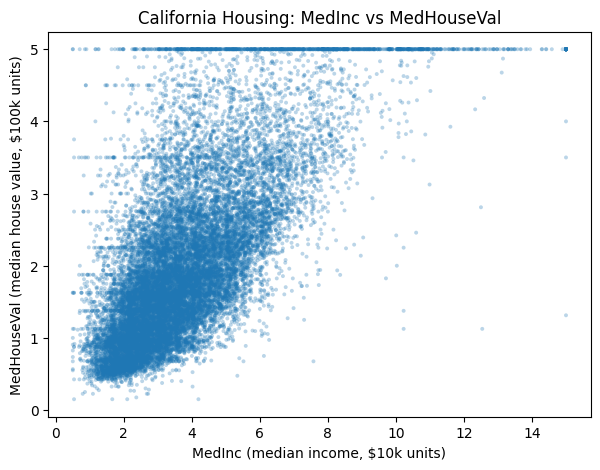

In [8]:
# Scatter plot of MedInc vs MedHouseVal
plt.figure(figsize=(7, 5))
plt.scatter(df["MedInc"], df["MedHouseVal"], s=8, alpha=0.3, edgecolors='none')
plt.xlabel("MedInc (median income, $10k units)")
plt.ylabel("MedHouseVal (median house value, $100k units)")
plt.title("California Housing: MedInc vs MedHouseVal")
plt.show()


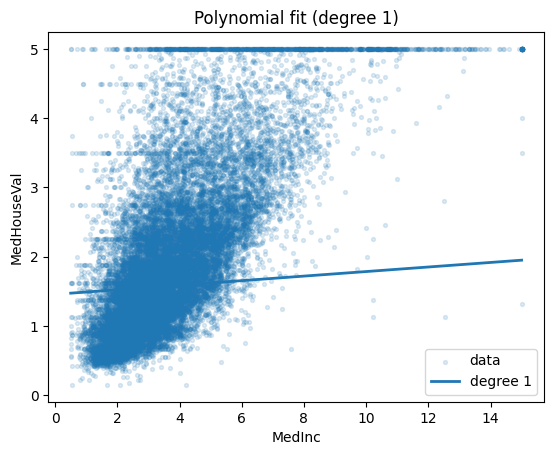

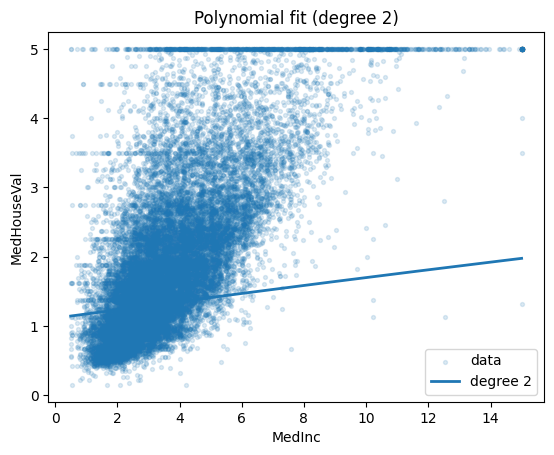

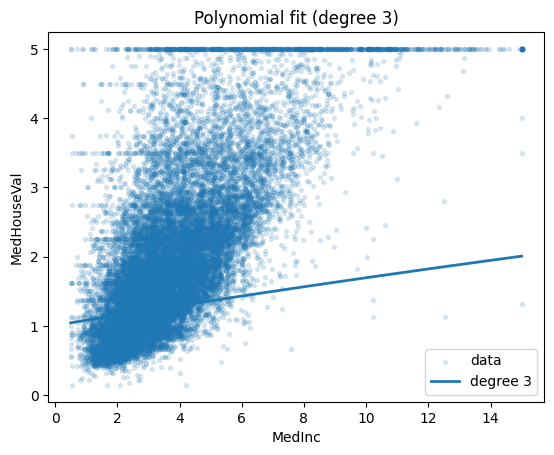

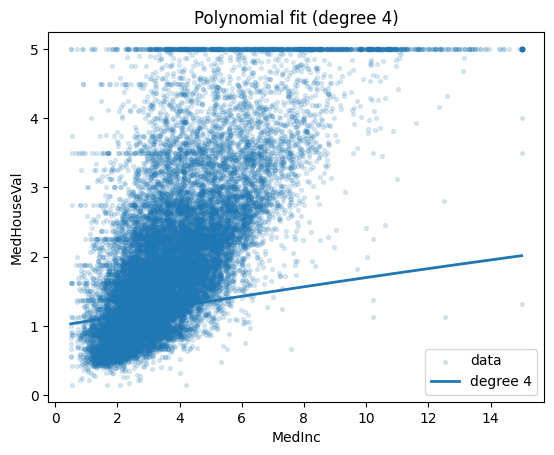

In [9]:
# Use different variable names to avoid overwriting x_data and y_data from earlier
x_housing = df["MedInc"].to_numpy(dtype=float)
y_housing = df["MedHouseVal"].to_numpy(dtype=float)

# Sort both x and y together to maintain the pairing
idx = np.argsort(x_housing)
x_housing_sorted = x_housing[idx]
y_housing_sorted = y_housing[idx]

for p in range(1,5):
    fit = np.polyfit(x_housing_sorted, y_housing_sorted, p)
    x_grid = np.linspace(x_housing_sorted.min(), x_housing_sorted.max(), 500)
    y_fit = np.polyval(fit, x_grid)

    plt.figure()
    plt.scatter(x_housing_sorted, y_housing_sorted, alpha=0.15, s=8, label="data")
    plt.plot(x_grid, y_fit, linewidth=2, label=f"degree {p}")
    plt.xlabel("MedInc")
    plt.ylabel("MedHouseVal")
    plt.title(f"Polynomial fit (degree {p})")
    plt.legend()
    plt.show()


There is a cap on median house value at 5.0, so I got rid of these maximums to see how the fit would perform:

In [10]:
def mse_kfold(x, y, p, k=5, seed=0):
    """
    Perform k-fold cross-validation for polynomial regression.
    
    Parameters:
    - x, y: input data (should NOT be pre-sorted)
    - p: polynomial degree
    - k: number of folds
    - seed: random seed for reproducibility
    
    Returns:
    - average training MSE, average validation MSE
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)
    rng = np.random.default_rng(seed)
    indices = rng.permutation(n)

    folds = np.array_split(indices, k)

    train_mses = []
    val_mses = []

    for fold_idx in range(k):
        val_idx = folds[fold_idx]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != fold_idx])

        x_train, y_train = x[train_idx], y[train_idx]

        x_val, y_val = x[val_idx], y[val_idx]

    print(f"Degree {p}: Train MSE = {train_mse:.4f}, Val MSE = {val_mse:.4f}")

        train_mses.append(mse(x_train, y_train, p))    train_mse, val_mse = mse_kfold(x_cv, y_cv, p, k=5)

for p in range(1, 6):

        fit = np.polyfit(x_train, y_train, p)print("\nTesting k-fold cross-validation on California Housing data:")

        beta_list = fit[::-1] # Example: Test different polynomial orders

        y_val_pred = yhat(x_val, beta_list)

y_cv = df["MedHouseVal"].to_numpy(dtype=float)

        val_mses.append(np.mean((y_val - y_val_pred) ** 2))x_cv = df["MedInc"].to_numpy(dtype=float)

# Use UNSORTED data for k-fold cross-validation

    return float(np.mean(train_mses)), float(np.mean(val_mses))

IndentationError: unindent does not match any outer indentation level (<string>, line 51)

Polynomial order 1 is most optimal as it has the lowest mse and is the simplest model that fits the data well. It seems like median house values have a predominantly linear relationship with median income. An issue I came across was this dataset has values capped at $500k so we cannot see a trend for larger values and the curve tries to fit this ceiling.  The fit also is very sensitive to big outliers and will shift to acommodate those outliers that are high income low house value